**[Cifar](https://www.cs.toronto.edu/~kriz/cifar.html):
The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.**

**The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 5000 images from each class.**

**Here are the classes in the dataset, as well as 10 random images from each:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import tarfile
import tensorflow as tf
from tensorflow import keras
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_squared_error, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.exceptions import ConvergenceWarning
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from matplotlib.ticker import FuncFormatter

%matplotlib inline
np.random.seed(1)

warnings.filterwarnings("ignore", category=ConvergenceWarning) 

**Processo de download automático dos dados**

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

170508288/170498071 [==============================] - 2s 0us/step


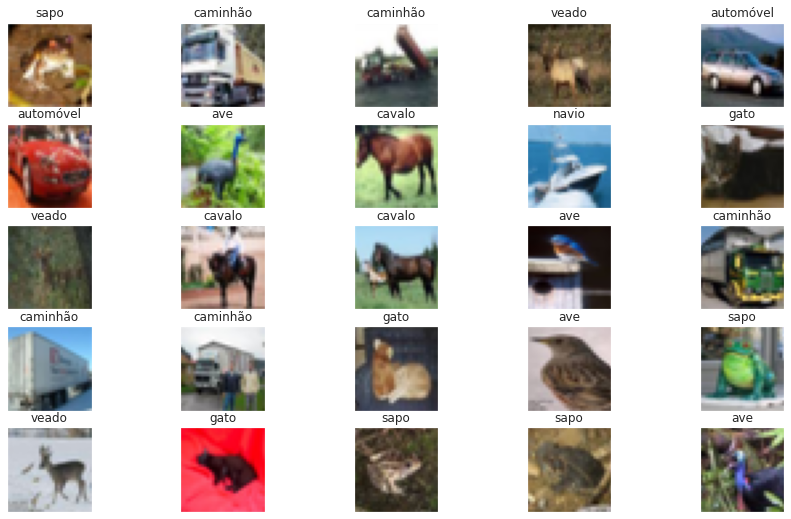

In [ ]:
label = ["Avião","automóvel","ave","gato","veado","cão","sapo","cavalo","navio","caminhão"]
sns.set()
fig, ax = plt.subplots(5,5,figsize=(15,9),subplot_kw={'xticks':(),'yticks':()})
ax = ax.ravel()
for i in range(25):
    ax[i].imshow(x_train[i])
    ax[i].set_title(label[y_train[i][0]])
plt.show()

**Tratamento de dados**

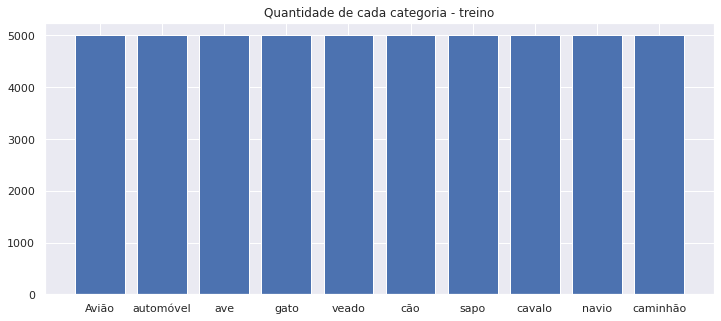

In [ ]:
plt.figure(figsize=(12,5))
unicos, contagem = np.unique(y_train, return_counts=True)
plt.bar(label, contagem)
plt.title("Quantidade de cada categoria - treino")
plt.show()

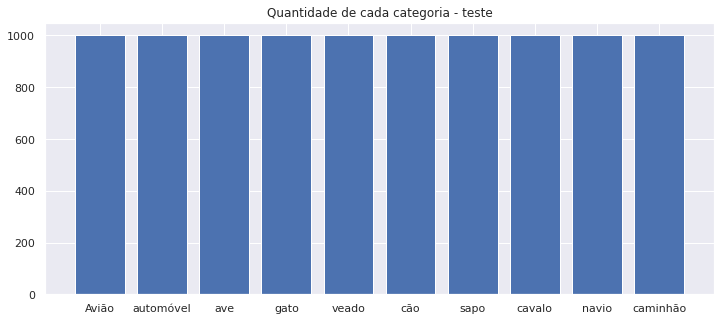

In [ ]:
plt.figure(figsize=(12,5))
unicos, contagem = np.unique(y_test, return_counts=True)
plt.bar(label, contagem)
plt.title("Quantidade de cada categoria - teste")
plt.show()

In [3]:
def plotarGrafico(historico,valor1,valor2,valor3,valor4):
    plt.figure(figsize=(10, 8))
    plt.plot(historico.history[valor1])
    plt.plot(historico.history[valor2])
    plt.title(valor3)
    plt.xlabel('Épocas')
    plt.ylabel(valor4)
    plt.legend(['Treino', 'Validação'])
    plt.show()

In [4]:
def prepararDatasetKeras(x_treino, x_teste, y_treino, y_teste):
  x_treino, x_validacao, y_treino, y_validacao = train_test_split(x_treino, y_treino, test_size=0.2)
  
  x_treino = x_treino / 255.
  x_validacao = x_validacao / 255.
  x_teste = x_teste / 255.

  y_treino = y_treino.squeeze()
  y_validacao = y_validacao.squeeze()
  y_teste = y_teste.squeeze()
  
  return x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste

In [5]:
def prepararDatasetScikitLearn(x_treino, x_teste, y_treino, y_teste):
  x_treino, x_validacao, y_treino, y_validacao = train_test_split(x_treino, y_treino, test_size=0.2)
  
  x_treino = (x_treino / 255.).reshape(x_treino.shape[0],-1)
  x_validacao = (x_validacao / 255.).reshape(x_validacao.shape[0],-1)
  x_teste = (x_teste / 255.).reshape(x_teste.shape[0],-1)

  y_treino = y_treino.squeeze()
  y_validacao = y_validacao.squeeze()
  y_teste = y_teste.squeeze()
  
  return x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste

In [6]:
def executarModelo(modelo,x_treino,x_validacao,y_treino,y_validacao,nome):
  treino_erro,validaca_erro = [],[]
  epocas = 100
  melhor_epoca = None
  melhor_modelo = None
  erro_minimo_validacao = float('inf')

  for epoca in range(epocas):
    modelo.fit(x_treino,y_treino) 

    y_treino_resposta = modelo.predict(x_treino)
    y_validacao_resposta = modelo.predict(x_validacao)

    treino_erro.append(mean_squared_error(y_treino,y_treino_resposta,squared=True))
    validaca_erro.append(mean_squared_error(y_validacao,y_validacao_resposta,squared=True))

    if validaca_erro[-1:][0] < erro_minimo_validacao:
      erro_minimo_validacao = validaca_erro[-1:][0]
      melhor_epoca = epoca + 1
      melhor_modelo = modelo

  y_pred = melhor_modelo.predict(x_validacao)

  print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
  print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
  print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')
  print(f"Melhor época: {melhor_epoca}")

  plt.figure(figsize=(12,5))
  plt.title(nome)

  plt.plot(treino_erro)
  plt.plot(validaca_erro)
  plt.title(f'Função de custo vs Número de Épocas - {nome}')
  plt.xlabel('Épocas')
  plt.ylabel("Função de Custo (J)")
  plt.legend(['Treino', 'Validação'])

  plt.show()

  return melhor_modelo

Acurácia do modelo na validação com melhor modelo é 36.68%.
Precisão do modelo na validação com melhor modelo é 36.68%.
Recall do modelo na validação com melhor modelo é 36.68%.
Melhor época: 96


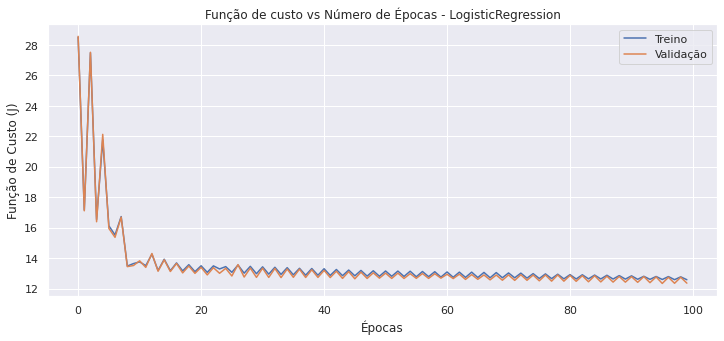

In [ ]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetScikitLearn(x_train, x_test, y_train, y_test)

modelo = executarModelo(LogisticRegression(solver="lbfgs", max_iter = 1,warm_start=True, multi_class="multinomial"),x_treino,x_validacao,y_treino,y_validacao,'LogisticRegression')

filename = 'modelo1.sav'
pickle.dump(modelo, open(filename, 'wb'))

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 3072)              0         
                                                                 
 dense (Dense)               (None, 300)               921900    
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 dense_2 (Dense)             (None, 10)                1010      
                                                                 
Total params: 953,010
Trainable params: 953,010
Non-trainable params: 0
_________________________________________________________________
Epoch 1/15
157/157 [==============================] - 4s 11ms/step - loss: 2.1675 - accuracy: 0.2934 - val_loss: 1.9935 - val_accuracy: 0.3405
Epoch 2/15
157/157 [===================

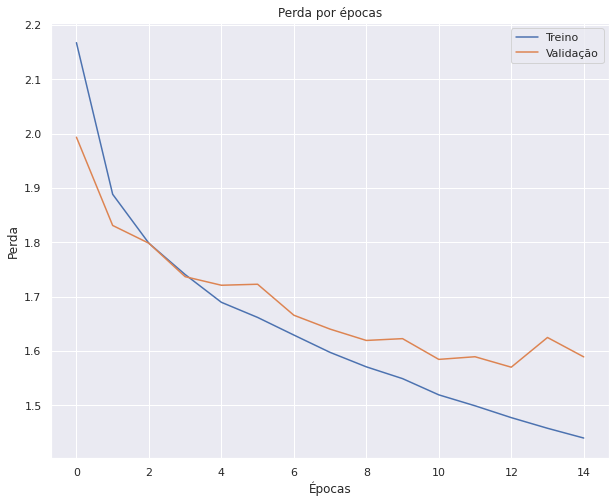

Acurácia do modelo na validação com melhor modelo é 48.88%.
Precisão do modelo na validação com melhor modelo é 48.88%.
Recall do modelo na validação com melhor modelo é 48.88%.


In [ ]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

tamanho_batch = 256
epocas = 15
nome = 'modelo1.h5'

callbacks=[keras.callbacks.ModelCheckpoint(filepath=nome,verbose=0,save_best_only=True)]

kernel_initializer = tf.keras.initializers.GlorotUniform(seed=None)
bias_initializer = tf.keras.initializers.Ones()
regularizer = tf.keras.regularizers.l2(1e-4)

modelo = keras.Sequential(
    [
        keras.Input(shape=(32,32,3,)),
        layers.Flatten(),
        layers.Dense(300, activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.Dense(100, activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.Dense(10, activation="softmax", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
    ]
)

modelo.summary()

modelo.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=3e-04, beta_1=0.9, beta_2=0.999, epsilon=1e-07), metrics=["accuracy"])

historico = modelo.fit(x_treino, y_treino, batch_size=tamanho_batch, epochs=epocas, validation_data=(x_validacao,y_validacao),validation_batch_size=tamanho_batch,callbacks=callbacks)

plotarGrafico(historico,"loss","val_loss","Perda por épocas","Perda")

modelo = keras.models.load_model(nome)

y_pred = modelo.predict(x_validacao)
y_pred = np.argmax(y_pred, axis=1)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 3072)              0         
                                                                 
 dense_3 (Dense)             (None, 300)               921900    
                                                                 
 dropout (Dropout)           (None, 300)               0         
                                                                 
 dense_4 (Dense)             (None, 100)               30100     
                                                                 
 dropout_1 (Dropout)         (None, 100)               0         
                                                                 
 dense_5 (Dense)             (None, 10)                1010      
                                                                 
Total params: 953,010
Trainable params: 953,010
Non-tr

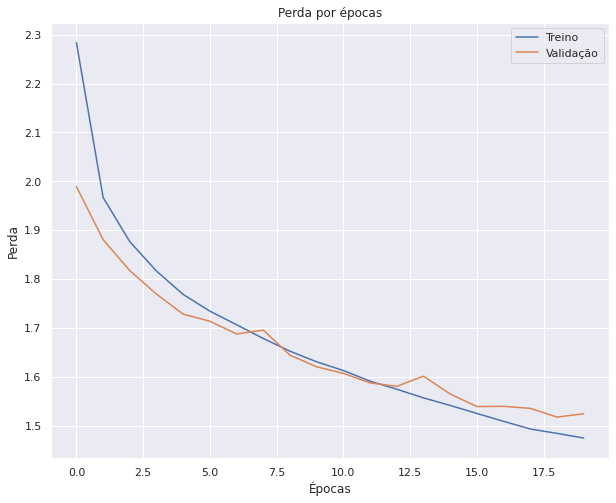

Acurácia do modelo na validação com melhor modelo é 50.56%.
Precisão do modelo na validação com melhor modelo é 50.56%.
Recall do modelo na validação com melhor modelo é 50.56%.


In [ ]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

tamanho_batch = 256
epocas = 20
nome = 'modelo2.h5'

callbacks=[keras.callbacks.ModelCheckpoint(filepath=nome,verbose=0,save_best_only=True)]

kernel_initializer = tf.keras.initializers.GlorotUniform(seed=None)
bias_initializer = tf.keras.initializers.Ones()
regularizer = tf.keras.regularizers.l2(1e-4)

modelo = keras.Sequential(
    [
        keras.Input(shape=(32,32,3,)),
        layers.Flatten(),
        layers.Dense(300, activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.Dropout(0.1),
        layers.Dense(100, activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.Dropout(0.1),
        layers.Dense(10, activation="softmax", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
    ]
)

modelo.summary()

modelo.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=3e-04, beta_1=0.9, beta_2=0.999, epsilon=1e-07), metrics=["accuracy"])

historico = modelo.fit(x_treino, y_treino, batch_size=tamanho_batch, epochs=epocas, validation_data=(x_validacao,y_validacao),validation_batch_size=tamanho_batch,callbacks=callbacks)

plotarGrafico(historico,"loss","val_loss","Perda por épocas","Perda")

modelo = keras.models.load_model(nome)

y_pred = modelo.predict(x_validacao)
y_pred = np.argmax(y_pred, axis=1)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 batch_normalization (BatchN  (None, 32, 32, 3)        12        
 ormalization)                                                   
                                                                 
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 batch_normalization_1 (Batc  (None, 32, 32, 32)       128       
 hNormalization)                                                 
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 32)       0         
 )                                                               
                                                      

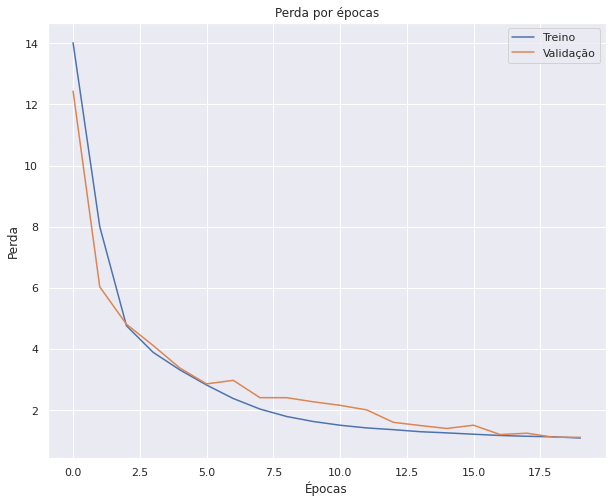

Acurácia do modelo na validação com melhor modelo é 68.54%.
Precisão do modelo na validação com melhor modelo é 68.54%.
Recall do modelo na validação com melhor modelo é 68.54%.


In [ ]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

tamanho_batch = 256
epocas = 20
nome = 'modelo3.h5'

callbacks=[keras.callbacks.ModelCheckpoint(filepath=nome,verbose=0,save_best_only=True)]

kernel_initializer = tf.keras.initializers.GlorotUniform(seed=None)
bias_initializer = tf.keras.initializers.Ones()
regularizer = tf.keras.regularizers.l2(1e-4)

modelo = keras.Sequential(
    [
        keras.Input(shape=(32,32,3,)),
     
        layers.BatchNormalization(),
        layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.BatchNormalization(),
        layers.Conv2D(32, kernel_size=(3, 3), padding='same', activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),

        layers.BatchNormalization(),
        layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.BatchNormalization(),
        layers.Conv2D(64, kernel_size=(3, 3), padding='same', activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),
     
        layers.Flatten(),
        layers.Dense(128, activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(10, activation="softmax", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
    ]
)

modelo.summary()

modelo.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=3e-04, beta_1=0.9, beta_2=0.999, epsilon=1e-07), metrics=["accuracy"])

historico = modelo.fit(x_treino, y_treino, batch_size=tamanho_batch, epochs=epocas, validation_data=(x_validacao,y_validacao),validation_batch_size=tamanho_batch,callbacks=callbacks)

plotarGrafico(historico,"loss","val_loss","Perda por épocas","Perda")

modelo = keras.models.load_model(nome)

y_pred = modelo.predict(x_validacao)
y_pred = np.argmax(y_pred, axis=1)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 1, 1, 512)         14714688  
                                                                 
 global_average_pooling2d_2   (None, 512)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_12 (Dense)            (None, 10)                5130      
                                                                 
Total params: 14,719,818
Trainable params: 5,130
Non-trainable params: 14,714,688
_________________________________________________________________
Epoch 1/20
157/157 [==============================] - 15s 90ms/step - loss: 2.1913 - accuracy: 0.2176 - val_loss: 1.9847 - val_accuracy: 0.3288
Epoch 2/20
157/157 [==============================] - 12s 79ms/step - loss: 1.8717 - accurac

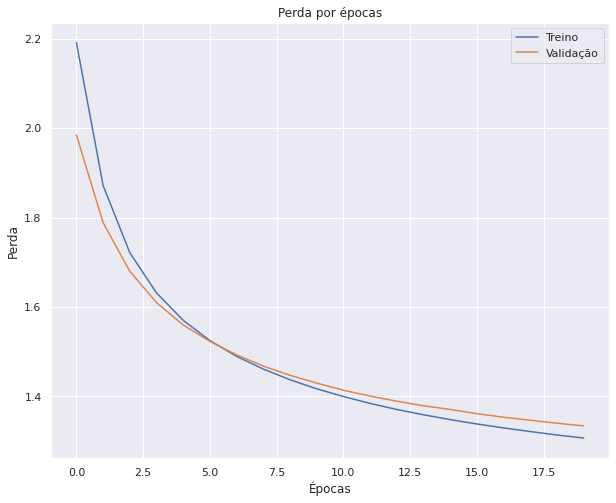

Acurácia do modelo na validação com melhor modelo é 54.51%.
Precisão do modelo na validação com melhor modelo é 54.51%.
Recall do modelo na validação com melhor modelo é 54.51%.


In [ ]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

tamanho_batch = 256
epocas = 20
nome = 'modelo4.h5'

checkpoint = keras.callbacks.ModelCheckpoint(filepath=nome,verbose=0,save_best_only=True)
early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
callbacks= [checkpoint,early]

kernel_initializer = tf.keras.initializers.GlorotUniform(seed=None)
bias_initializer = tf.keras.initializers.Ones()
regularizer = tf.keras.regularizers.l2(1e-4)

# Carregamento do modelo pré-treinado SEM as camadas densas (include_top = False)
vgg16 = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3,))

# Congela camadas pré-treinadas
for layer in vgg16.layers:
  layer.trainable = False

modelo = keras.Sequential(
    [
        vgg16,
        layers.GlobalAveragePooling2D(),
        layers.Dense(10, activation="softmax", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
    ]
)

modelo.summary()

modelo.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=3e-04, beta_1=0.9, beta_2=0.999, epsilon=1e-07), metrics=["accuracy"])

historico = modelo.fit(x_treino, y_treino, batch_size=tamanho_batch, epochs=epocas, validation_data=(x_validacao,y_validacao),validation_batch_size=tamanho_batch,callbacks=callbacks)

plotarGrafico(historico,"loss","val_loss","Perda por épocas","Perda")

modelo = keras.models.load_model(nome)

y_pred = modelo.predict(x_validacao)
y_pred = np.argmax(y_pred, axis=1)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 1, 1, 512)         14714688  
                                                                 
 global_average_pooling2d_3   (None, 512)              0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_13 (Dense)            (None, 10)                5130      
                                                                 
Total params: 14,719,818
Trainable params: 14,719,818
Non-trainable params: 0
_________________________________________________________________
Epoch 1/20
157/157 [==============================] - 37s 217ms/step - loss: 1.4248 - accuracy: 0.4761 - val_loss: 0.8840 - val_accuracy: 0.6902
Epoch 2/20
157/157 [==============================] - 33s 210ms/step - loss: 0.7024 - accuracy:

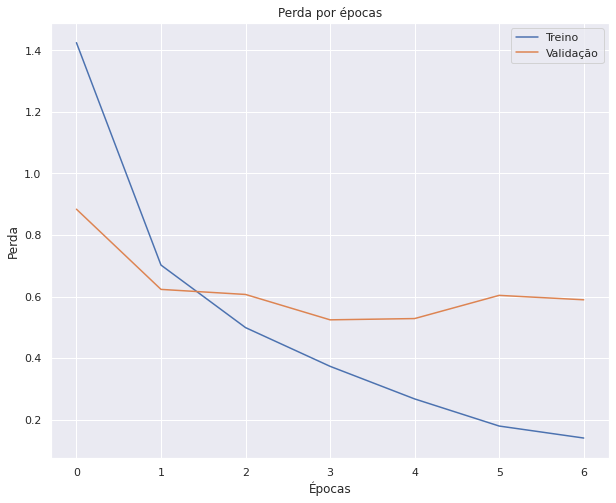

Acurácia do modelo na validação com melhor modelo é 83.06%.
Precisão do modelo na validação com melhor modelo é 83.06%.
Recall do modelo na validação com melhor modelo é 83.06%.


In [ ]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

tamanho_batch = 256
epocas = 20
nome = 'modelo5.h5'

checkpoint = keras.callbacks.ModelCheckpoint(filepath=nome,verbose=0,save_best_only=True)
early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
callbacks= [checkpoint,early]

kernel_initializer = tf.keras.initializers.GlorotUniform(seed=None)
bias_initializer = tf.keras.initializers.Ones()
regularizer = tf.keras.regularizers.l2(1e-4)

# Carregamento do modelo pré-treinado SEM as camadas densas (include_top = False)
vgg16 = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3,))

# Descongela camadas pré-treinadas
for layer in vgg16.layers:
  layer.trainable = True

modelo = keras.Sequential(
    [
        vgg16,
        layers.GlobalAveragePooling2D(),
        layers.Dense(10, activation="softmax", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
    ]
)

modelo.summary()

modelo.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=3e-04, beta_1=0.9, beta_2=0.999, epsilon=1e-07), metrics=["accuracy"])

historico = modelo.fit(x_treino, y_treino, batch_size=tamanho_batch, epochs=epocas, validation_data=(x_validacao,y_validacao),validation_batch_size=tamanho_batch,callbacks=callbacks)

plotarGrafico(historico,"loss","val_loss","Perda por épocas","Perda")

modelo = keras.models.load_model(nome)

y_pred = modelo.predict(x_validacao)
y_pred = np.argmax(y_pred, axis=1)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

58900480/58889256 [==============================] - 1s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 1, 1, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 512)               0         
                                                                 
 dense (Dense)               (None, 4096)              2101248   
                                                                 
 dense_1 (Dense)             (None, 4096)              16781312  
                                                                 
 dense_2 (Dense)             (None, 10)                40970     
                                                                 
Total params: 33,638,218
Trainable params: 33,638,218
Non-trainable params: 0
_____________________________________________

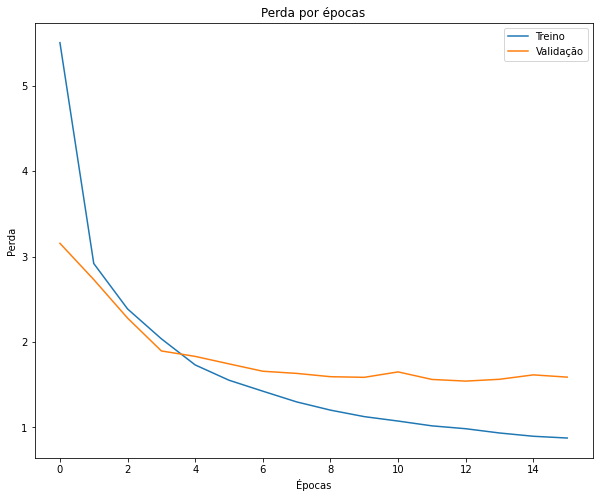

Acurácia do modelo na validação com melhor modelo é 83.38%.
Precisão do modelo na validação com melhor modelo é 83.38%.
Recall do modelo na validação com melhor modelo é 83.38%.


In [7]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

tamanho_batch = 256
epocas = 50
nome = 'modelo6.h5'

checkpoint = keras.callbacks.ModelCheckpoint(filepath=nome,verbose=0,save_best_only=True)
early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
callbacks= [checkpoint,early]

kernel_initializer = tf.keras.initializers.GlorotUniform(seed=None)
bias_initializer = tf.keras.initializers.Ones()
regularizer = tf.keras.regularizers.l2(1e-4)

# Carregamento do modelo pré-treinado SEM as camadas densas (include_top = False)
vgg16 = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3,))

# Descongela camadas pré-treinadas
for layer in vgg16.layers:
  layer.trainable = True

modelo = keras.Sequential(
    [
        vgg16,
        #layers.GlobalAveragePooling2D(),
        layers.Flatten(),
        layers.Dense(4096, activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.Dense(4096, activation="relu", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
        layers.Dense(10, activation="softmax", kernel_initializer=kernel_initializer, bias_initializer=bias_initializer, kernel_regularizer=regularizer, bias_regularizer=regularizer, activity_regularizer=regularizer),
    ]
)

modelo.summary()

modelo.compile(loss="sparse_categorical_crossentropy", optimizer=tf.keras.optimizers.Adam(learning_rate=3e-04, beta_1=0.9, beta_2=0.999, epsilon=1e-07), metrics=["accuracy"])

historico = modelo.fit(x_treino, y_treino, batch_size=tamanho_batch, epochs=epocas, validation_data=(x_validacao,y_validacao),validation_batch_size=tamanho_batch,callbacks=callbacks)

plotarGrafico(historico,"loss","val_loss","Perda por épocas","Perda")

modelo = keras.models.load_model(nome)

y_pred = modelo.predict(x_validacao)
y_pred = np.argmax(y_pred, axis=1)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

In [8]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

extrator = keras.models.load_model('modelo6.h5')
extrator = Model(inputs=extrator.input, outputs=extrator.get_layer('dense_1').output)

x_extrator_validacao = extrator.predict(x_validacao)
x_extrator_treino = extrator.predict(x_treino)

modelo = LogisticRegression()
modelo.fit(x_extrator_treino, y_treino)

filename = 'modelo7.sav'
pickle.dump(modelo, open(filename, 'wb'))

y_pred = modelo.predict(x_extrator_validacao)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

Acurácia do modelo na validação com melhor modelo é 95.74%.
Precisão do modelo na validação com melhor modelo é 95.74%.
Recall do modelo na validação com melhor modelo é 95.74%.


In [9]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

extrator = keras.models.load_model('modelo6.h5')
extrator = Model(inputs=extrator.input, outputs=extrator.get_layer('dense_1').output)

x_extrator_validacao = extrator.predict(x_validacao)
x_extrator_treino = extrator.predict(x_treino)

modelo = SVC()
modelo.fit(x_extrator_treino, y_treino)

filename = 'modelo8.sav'
pickle.dump(modelo, open(filename, 'wb'))

y_pred = modelo.predict(x_extrator_validacao)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

Acurácia do modelo na validação com melhor modelo é 95.97%.
Precisão do modelo na validação com melhor modelo é 95.97%.
Recall do modelo na validação com melhor modelo é 95.97%.


In [10]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

extrator = keras.models.load_model('modelo6.h5')
extrator = Model(inputs=extrator.input, outputs=extrator.get_layer('dense_1').output)

x_extrator_validacao = extrator.predict(x_validacao)
x_extrator_treino = extrator.predict(x_treino)

modelo = RandomForestClassifier()
modelo.fit(x_extrator_treino, y_treino)

filename = 'modelo9.sav'
pickle.dump(modelo, open(filename, 'wb'))

y_pred = modelo.predict(x_extrator_validacao)

print(f'Acurácia do modelo na validação com melhor modelo é {round(accuracy_score(y_validacao, y_pred)*100,2)}%.')
print(f'Precisão do modelo na validação com melhor modelo é {round(precision_score(y_validacao, y_pred, average="micro")*100,2)}%.')
print(f'Recall do modelo na validação com melhor modelo é {round(recall_score(y_validacao, y_pred, average="micro")*100,2)}%.')

Acurácia do modelo na validação com melhor modelo é 95.7%.
Precisão do modelo na validação com melhor modelo é 95.7%.
Recall do modelo na validação com melhor modelo é 95.7%.


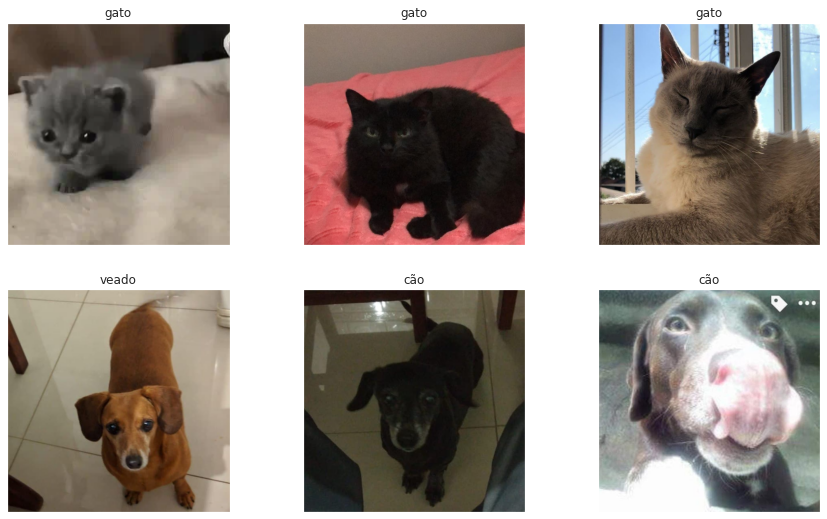

In [ ]:
filename = 'modelo8.sav' #Modelo com SVC
modelo = pickle.load(open(filename, 'rb'))

extrator = keras.models.load_model('modelo6.h5')
extrator = Model(inputs=extrator.input, outputs=extrator.get_layer('dense_5').output)

label = ["Avião","automóvel","ave","gato","veado","cão","sapo","cavalo","navio","caminhão"]
imagens = ['gato1.png','gato2.png','gato3.png','cachorro1.png','cachorro2.png','cachorro3.png']

sns.set()
fig, ax = plt.subplots(2,3,figsize=(15,9),subplot_kw={'xticks':(),'yticks':()})
ax = ax.ravel()

for img,i in zip(imagens,range(6)):
  ax[i].imshow(image.load_img(img))
  img = image.load_img(img, target_size=(32, 32, 3))
  img = image.img_to_array(img)
  img = img / 255.
  img = extrator.predict(img.reshape(1,32,32,3))
  y_pred = modelo.predict(img)
  ax[i].set_title(label[y_pred[0]])

plt.show()

In [13]:
def matrixConfusao(modelo,x_teste,y_teste,nome,keras):
  if(keras):
    y_pred = modelo.predict(x_teste)
    y_pred = np.argmax(y_pred, axis=1)
  else:
    y_pred = modelo.predict(x_teste)

  print(f'Acurácia do modelo no teste com {nome} é {round(accuracy_score(y_teste, y_pred)*100,2)}%.')
  print(f'Precisão do modelo teste com {nome} é {round(precision_score(y_teste, y_pred, average="micro")*100,2)}%.')
  print(f'Recall do modelo teste com {nome} é {round(recall_score(y_teste, y_pred, average="micro")*100,2)}%.')

  n_features = 10

  label = ["Avião","automóvel","ave","gato","veado","cão","sapo","cavalo","navio","caminhão"]

  cf_matrix = confusion_matrix(y_teste,y_pred)
  df_cm = pd.DataFrame(cf_matrix/cf_matrix.sum(axis=1).reshape(n_features,1), index=label, columns=label)

  list_texto = cf_matrix.tolist()
  for i in range(n_features):
    list_texto[i][i] = f"{list_texto[i][i]}/{(y_teste == i).sum()}"

  df_texto = pd.DataFrame(list_texto, index=label, columns=label).astype('string')

  sns.set(font_scale=1.4)
  fig, ax = plt.subplots(figsize=(18,15),dpi=65)
  fmt = lambda x,pos: '{:.0%}'.format(x)
  sns.heatmap(df_cm, annot=True, annot_kws={"size": 14,'va':'bottom'}, cmap='Blues', ax=ax, fmt='.2%',cbar_kws={'format': FuncFormatter(fmt)})
  sns.heatmap(df_cm, annot=df_texto, annot_kws={"size": 14,'va':'top'}, cmap='Blues',fmt='', ax=ax, cbar=False)

  plt.title(f"Matriz de Confusão da {nome}")
  plt.xlabel("Predito")
  plt.ylabel("Correto")

  plt.show()

Acurácia do modelo no teste com VGG16 é 82.43%.
Precisão do modelo teste com VGG16 é 82.43%.
Recall do modelo teste com VGG16 é 82.43%.


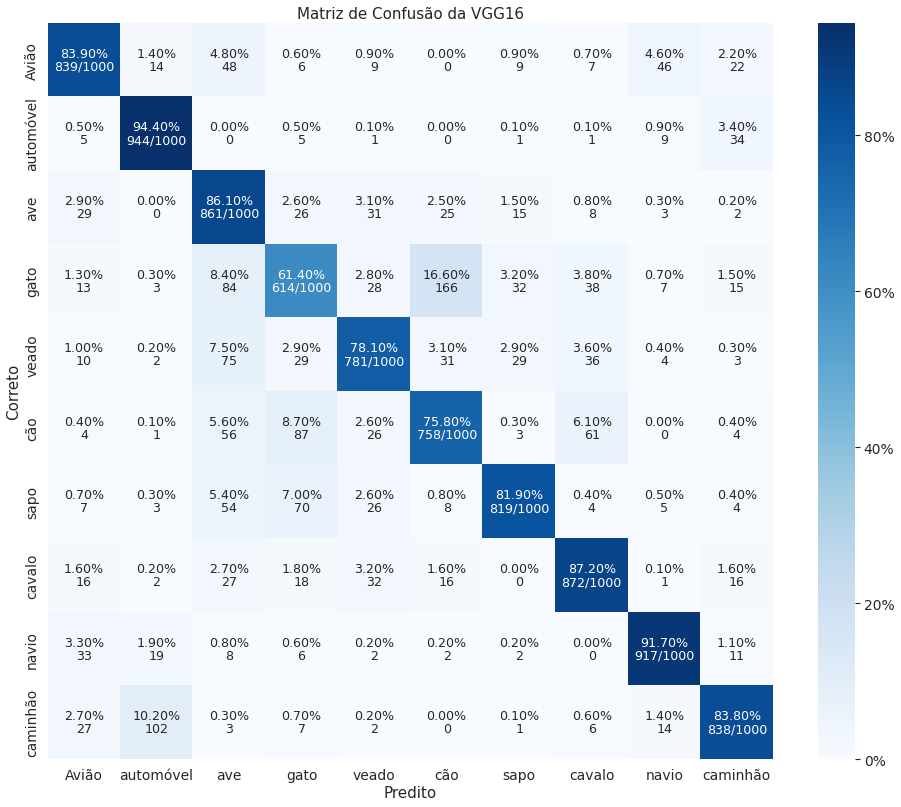

In [14]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

modelo = keras.models.load_model('modelo6.h5')

matrixConfusao(modelo,x_teste,y_teste,"VGG16",True)

Acurácia do modelo no teste com SVC é 83.55%.
Precisão do modelo teste com SVC é 83.55%.
Recall do modelo teste com SVC é 83.55%.


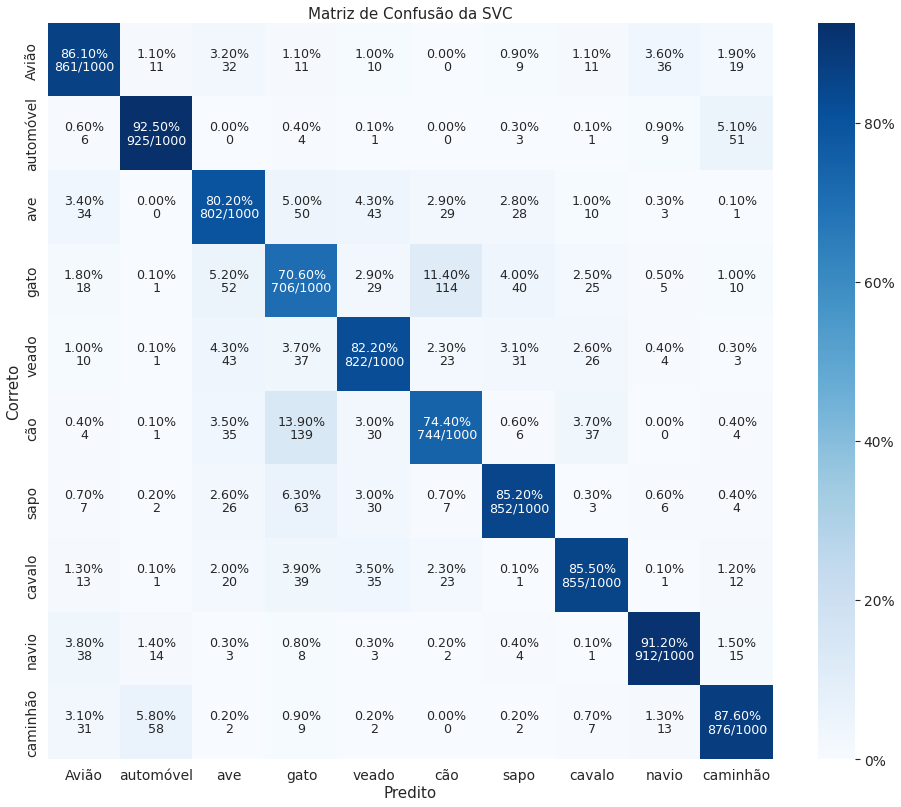

In [19]:
x_treino, x_validacao, x_teste, y_treino, y_validacao, y_teste = prepararDatasetKeras(x_train, x_test, y_train, y_test)

extrator = keras.models.load_model('modelo6.h5')
extrator = Model(inputs=extrator.input, outputs=extrator.get_layer('dense_1').output)
x_extrator_teste = extrator.predict(x_teste)

filename = 'modelo8.sav' #Modelo com SVC
modelo = pickle.load(open(filename, 'rb'))

matrixConfusao(modelo,x_extrator_teste,y_teste,"SVC",False)